<div dir=rtl style="text-align: right">

# שיעור 1 — מה זה רשת נוירונים ו-SGD?

## הרעיון המרכזי

רשת נוירונים היא בסך הכל **פונקציה עם פרמטרים** — כמו משפחה של עקומות.  
המטרה: למצוא את הפרמטרים שגורמים לפונקציה **להתאים הכי טוב לנתונים**.

בשיעור זה נדגים את הרעיון הזה בדוגמה פשוטה ומוחשית:  
**נחפש את הפרבולה שמתאימה ביותר לקבוצת נקודות.**

---

## המשפחה שלנו

$$f(x) = ax^2 + bx - 2$$

הפרמטרים הם $a$ ו-$b$. הקבוע $-2$ קבוע מראש.  
השאלה: **אילו $a, b$ מתאימים הכי טוב לנתונים?**

</div>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13

<div dir=rtl style="text-align: right">

## שלב 1 — יצירת הנתונים

נגריל פרבולה אמיתית עם מקדמים $a^*, b^*$ אקראיים, ניצור 100 נקודות לאורכה, ונוסיף רעש גאוסיאני.

</div>

פרבולה אמיתית: f(x) = -0.376·x² + 2.704·x - 2


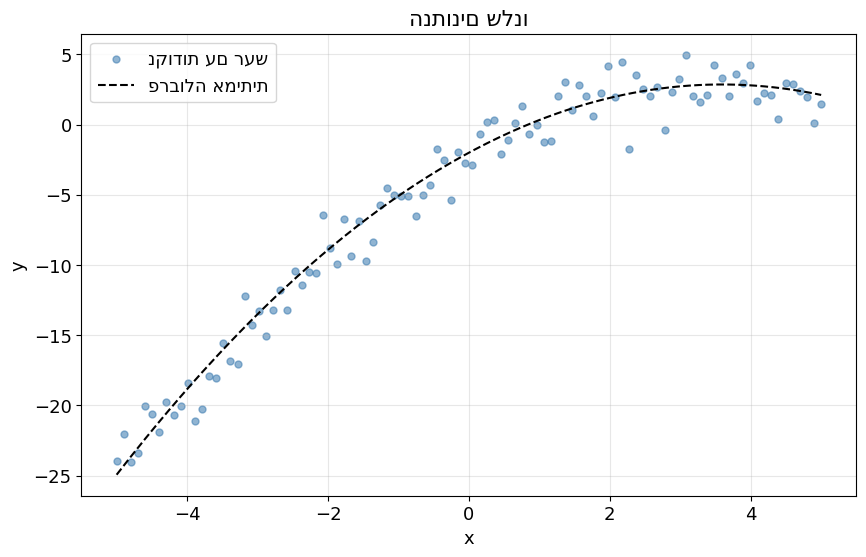

In [11]:
np.random.seed(42)

# הפרבולה ה"אמיתית"
a_true = np.random.uniform(-1.5, 1.5)
b_true = np.random.uniform(-3, 3)
c_true = -2  # קבוע

print(f"פרבולה אמיתית: f(x) = {a_true:.3f}·x² + {b_true:.3f}·x - 2")

# 100 נקודות
x = np.linspace(-5, 5, 100)
noise = np.random.normal(0, 1.5, size=100)
y = a_true * x**2 + b_true * x + c_true + noise

# הצגה
plt.scatter(x, y, color='steelblue', alpha=0.6, s=25, label='נקודות עם רעש')
x_plot = np.linspace(-5, 5, 300)
plt.plot(x_plot, a_true * x_plot**2 + b_true * x_plot + c_true,
         'k--', linewidth=1.5, label='פרבולה אמיתית')
plt.legend()
plt.title('הנתונים שלנו')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

<div dir=rtl style="text-align: right">

## שלב 2 — פונקציית ה-Loss

איך נמדוד כמה טובה פרבולה מסוימת?  
**סכום ריבועי המרחקים האנכיים** בין כל נקודה לבין הפרבולה:

$$L(a, b) = \sum_{i=1}^{N} \left( y_i - f(x_i) \right)^2 = \sum_{i=1}^{N} \left( y_i - ax_i^2 - bx_i + 2 \right)^2$$

ככל ש-$L$ קטן יותר — הפרבולה מתאימה טוב יותר.

</div>

In [12]:
def loss(a, b, x, y):
    """סכום ריבועי השגיאות"""
    predictions = a * x**2 + b * x - 2
    return np.sum((y - predictions)**2)

# בואו נראה את ה-loss של הפרבולה האמיתית לעומת פרבולה שרירותית
print(f"Loss של הפרבולה האמיתית:     {loss(a_true, b_true, x, y):.1f}")
print(f"Loss של הפרבולה a=0, b=0:    {loss(0, 0, x, y):.1f}")
print(f"Loss של הפרבולה a=1, b=1:    {loss(1, 1, x, y):.1f}")

Loss של הפרבולה האמיתית:     190.5
Loss של הפרבולה a=0, b=0:    8423.8
Loss של הפרבולה a=1, b=1:    27772.6


<div dir=rtl style="text-align: right">

## שלב 3 — נוף ה-Loss

ה-Loss הוא פונקציה של $a$ ו-$b$. בואו נצייר אותו ונראה איך הוא נראה.

אנחנו מחפשים את **השפל** — הנקודה עם ה-Loss הנמוך ביותר.

</div>

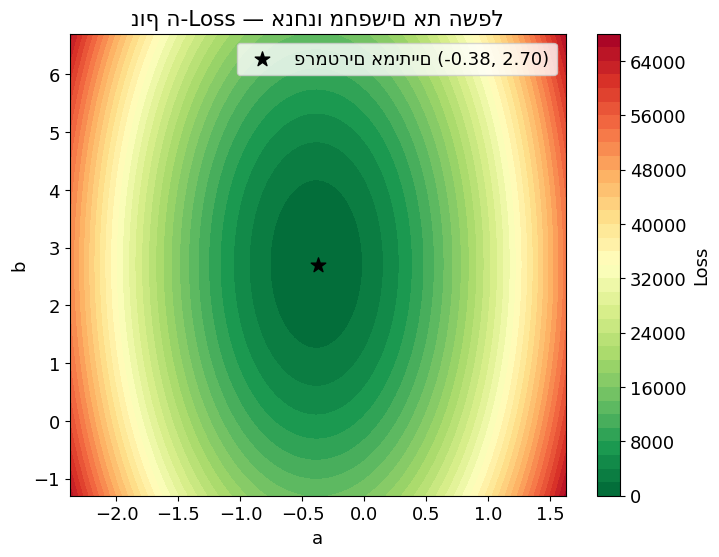

In [13]:
# רשת של ערכי a, b
a_range = np.linspace(a_true - 2, a_true + 2, 200)
b_range = np.linspace(b_true - 4, b_true + 4, 200)
A, B = np.meshgrid(a_range, b_range)

# חישוב loss לכל צירוף
L = np.array([[loss(a, b, x, y) for a in a_range] for b in b_range])

plt.figure(figsize=(8, 6))
cp = plt.contourf(A, B, L, levels=40, cmap='RdYlGn_r')
plt.colorbar(cp, label='Loss')
plt.scatter([a_true], [b_true], color='black', s=120, zorder=5,
            marker='*', label=f'פרמטרים אמיתיים ({a_true:.2f}, {b_true:.2f})')
plt.xlabel('a')
plt.ylabel('b')
plt.title('נוף ה-Loss — אנחנו מחפשים את השפל')
plt.legend()
plt.show()

<div dir=rtl style="text-align: right">

## שלב 4 — גרדיאנט: לאן "יורד" ה-Loss?

הגרדיאנט $\nabla L$ הוא הוקטור שמצביע לכיוון **העלייה התלולה ביותר**.  
לכן נצעד **נגד** הגרדיאנט.

נגזור אנליטית:

$$\frac{\partial L}{\partial a} = -2 \sum_i (y_i - f(x_i)) \cdot x_i^2$$

$$\frac{\partial L}{\partial b} = -2 \sum_i (y_i - f(x_i)) \cdot x_i$$

</div>

In [14]:
def gradients(a, b, x, y):
    """נגזרות חלקיות של ה-loss לפי a ו-b"""
    residuals = y - (a * x**2 + b * x - 2)  # השגיאות
    dL_da = -2 * np.sum(residuals * x**2)
    dL_db = -2 * np.sum(residuals * x)
    return dL_da, dL_db

<div dir=rtl style="text-align: right">

## שלב 5 — Gradient Descent

האלגוריתם פשוט:

$$a \leftarrow a - \eta \cdot \frac{\partial L}{\partial a}$$
$$b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

כאשר $\eta$ (eta) הוא **קצב הלמידה** — גודל הצעד.

</div>

In [15]:
# נקודת פתיחה ופרמטרים
a = 0.0
b = 0.0
lr = 1e-5  # קצב למידה
n_steps = 500

# שמירת ההיסטוריה
history_a = [a]
history_b = [b]
history_loss = [loss(a, b, x, y)]

for step in range(n_steps):
    da, db = gradients(a, b, x, y)
    a -= lr * da
    b -= lr * db
    history_a.append(a)
    history_b.append(b)
    history_loss.append(loss(a, b, x, y))

print(f"פרמטרים אמיתיים:  a={a_true:.4f}, b={b_true:.4f}")
print(f"פרמטרים שנמצאו:   a={a:.4f}, b={b:.4f}")
print(f"Loss סופי: {history_loss[-1]:.1f}")

פרמטרים אמיתיים:  a=-0.3764, b=2.7043
פרמטרים שנמצאו:   a=-0.3885, b=2.7155
Loss סופי: 188.4


<div dir=rtl style="text-align: right">

## שלב 6 — גרף ה-Loss לאורך הלמידה

</div>

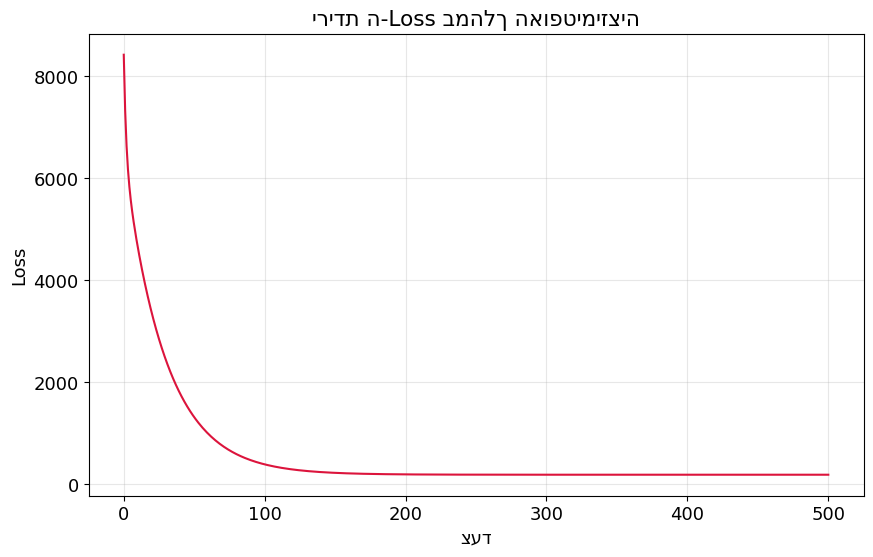

In [16]:
plt.plot(history_loss, color='crimson')
plt.xlabel('צעד')
plt.ylabel('Loss')
plt.title('ירידת ה-Loss במהלך האופטימיזציה')
plt.grid(True, alpha=0.3)
plt.show()

<div dir=rtl style="text-align: right">

## שלב 7 — המסלול על נוף ה-Loss

</div>

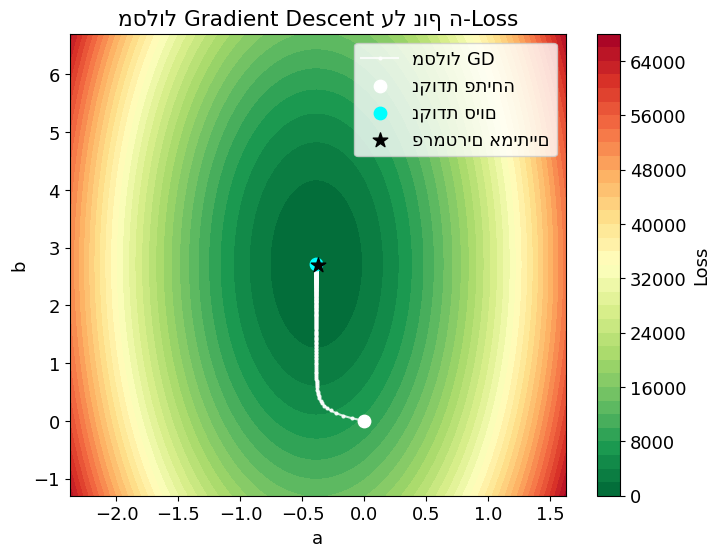

In [17]:
plt.figure(figsize=(8, 6))
cp = plt.contourf(A, B, L, levels=40, cmap='RdYlGn_r')
plt.colorbar(cp, label='Loss')

# מסלול האופטימיזציה
plt.plot(history_a, history_b, 'w-o', markersize=2, linewidth=1.5,
         alpha=0.8, label='מסלול GD')
plt.scatter([history_a[0]], [history_b[0]], color='white', s=80,
            zorder=6, label='נקודת פתיחה')
plt.scatter([history_a[-1]], [history_b[-1]], color='cyan', s=80,
            zorder=6, label='נקודת סיום')
plt.scatter([a_true], [b_true], color='black', s=120, zorder=7,
            marker='*', label='פרמטרים אמיתיים')

plt.xlabel('a')
plt.ylabel('b')
plt.title('מסלול Gradient Descent על נוף ה-Loss')
plt.legend()
plt.show()

<div dir=rtl style=\"text-align: right\">

## שלב 7.5 — המסלול בתלת-ממד

עכשיו נראה את אותו מסלול, אבל על **המשטח עצמו** — ה-Loss כציר Z.  
ניתן לראות בבירור איך האלגוריתם "מחליק במדרון" לעבר השפל.

</div>

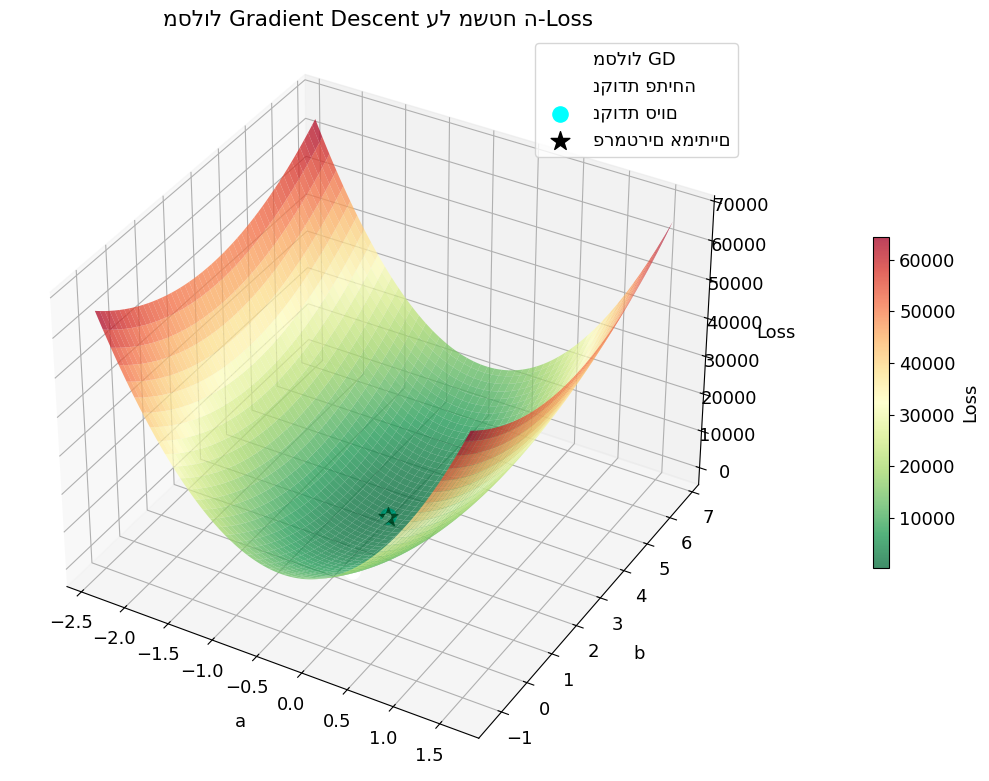

In [18]:
import plotly.graph_objects as go

# חישוב Loss לכל נקודה במסלול
path_loss = [loss(ha, hb, x, y) for ha, hb in zip(history_a, history_b)]

# דגימה כל 5 צעדים
step = 5
ha = history_a[::step]
hb = history_b[::step]
hl = path_loss[::step]

fig = go.Figure()

# משטח ה-Loss
fig.add_trace(go.Surface(
    x=A, y=B, z=L,
    colorscale='RdYlGn',
    reversescale=True,
    opacity=0.8,
    showscale=True,
    colorbar=dict(title='Loss'),
    name='Loss surface'
))

# מסלול GD
fig.add_trace(go.Scatter3d(
    x=ha, y=hb, z=hl,
    mode='lines+markers',
    line=dict(color='deeppink', width=5),
    marker=dict(size=3, color='deeppink'),
    name='מסלול GD'
))

# נקודת פתיחה
fig.add_trace(go.Scatter3d(
    x=[history_a[0]], y=[history_b[0]], z=[path_loss[0]],
    mode='markers',
    marker=dict(size=10, color='yellow', symbol='circle', line=dict(color='black', width=1)),
    name='נקודת פתיחה'
))

# נקודת סיום
fig.add_trace(go.Scatter3d(
    x=[history_a[-1]], y=[history_b[-1]], z=[path_loss[-1]],
    mode='markers',
    marker=dict(size=10, color='cyan', symbol='circle', line=dict(color='black', width=1)),
    name='נקודת סיום'
))

# פרמטרים אמיתיים
fig.add_trace(go.Scatter3d(
    x=[a_true], y=[b_true], z=[loss(a_true, b_true, x, y)],
    mode='markers',
    marker=dict(size=10, color='black', symbol='diamond'),
    name='פרמטרים אמיתיים'
))

fig.update_layout(
    title='מסלול Gradient Descent על משטח ה-Loss — סובב עם העכבר',
    scene=dict(
        xaxis_title='a',
        yaxis_title='b',
        zaxis_title='Loss',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2))
    ),
    width=900,
    height=650,
    legend=dict(x=0, y=1)
)

fig.show()

<div dir=rtl style="text-align: right">

## שלב 8 — הפרבולה שנמצאה מול הנקודות

</div>

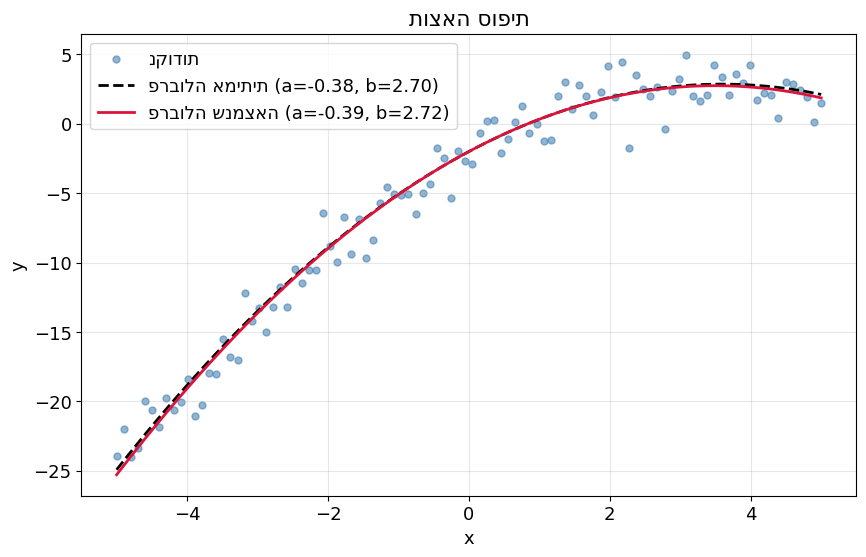

In [19]:
plt.scatter(x, y, color='steelblue', alpha=0.6, s=25, label='נקודות')

x_plot = np.linspace(-5, 5, 300)
plt.plot(x_plot, a_true * x_plot**2 + b_true * x_plot - 2,
         'k--', linewidth=2, label=f'פרבולה אמיתית (a={a_true:.2f}, b={b_true:.2f})')
plt.plot(x_plot, a * x_plot**2 + b * x_plot - 2,
         'crimson', linewidth=2, label=f'פרבולה שנמצאה (a={a:.2f}, b={b:.2f})')

plt.legend()
plt.title('תוצאה סופית')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

<div dir=rtl style="text-align: right">

## ניסוי — שחקו עם הפרמטרים

שנו את הערכים הבאים ובדקו מה קורה:

| פרמטר | מה לנסות |
|--------|----------|
| `lr` | נסו `1e-4` — מה קורה? נסו `1e-7` — כמה צעדים צריך? |
| `n_steps` | מה קורה עם 50 צעדים? עם 2000? |
| `a, b` (נקודת פתיחה) | נסו `a=5, b=-5` — האם מגיעים לאותו מקום? |
| `noise` | שנו את `1.5` ל-`0` או ל-`5` — מה ה-loss הסופי? |

</div>

<div dir=rtl style="text-align: right">

---

## סיכום

| מושג | בדוגמה שלנו | ברשת נוירונים |
|------|-------------|----------------|
| **פונקציה עם פרמטרים** | $f(x)=ax^2+bx-2$ | שכבות עם משקולות |
| **נתוני אימון** | 100 נקודות $(x_i, y_i)$ | אלפי/מיליוני דוגמאות |
| **Loss** | סכום ריבועי שגיאות | Cross-entropy, MSE, ... |
| **פרמטרים** | $a, b$ (2 פרמטרים) | מיליוני משקולות |
| **אופטימיזציה** | Gradient Descent | SGD, Adam, ... |

**הרעיון זהה לחלוטין** — רק הסדר של גדלות שונה.

</div>